In [1]:
import pandas as pd
import yfinance as yf 
import matplotlib.pyplot as plt

In [2]:
sp500 = yf.download("^GSPC", start="2000-01-01", end="2024-12-31")
vix = yf.download("^VIX", start="2000-01-01", end="2024-12-31")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:

sp500.head()
sp500.info()
sp500.isnull().sum()
sp500.columns = sp500.columns.get_level_values(0)

vix.head()
vix.info()
vix.isnull().sum()
vix.columns = vix.columns.get_level_values(0)



<class 'pandas.DataFrame'>
DatetimeIndex: 6288 entries, 2000-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   6288 non-null   float64
 1   (High, ^GSPC)    6288 non-null   float64
 2   (Low, ^GSPC)     6288 non-null   float64
 3   (Open, ^GSPC)    6288 non-null   float64
 4   (Volume, ^GSPC)  6288 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.8 KB
<class 'pandas.DataFrame'>
DatetimeIndex: 6288 entries, 2000-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^VIX)   6288 non-null   float64
 1   (High, ^VIX)    6288 non-null   float64
 2   (Low, ^VIX)     6288 non-null   float64
 3   (Open, ^VIX)    6288 non-null   float64
 4   (Volume, ^VIX)  6288 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.8 KB


In [4]:
# daily returns 

sp500['returns'] = sp500['Close'].pct_change()
vix['returns'] = vix['Close'].pct_change()

sp500[['Close', 'returns']].head()

Price,Close,returns
Date,,
2000-01-03,1455.219971,NaN
2000-01-04,1399.420044,-0.038345
2000-01-05,1402.109985,0.001922
2000-01-06,1403.449951,0.000956
2000-01-07,1441.469971,0.027090


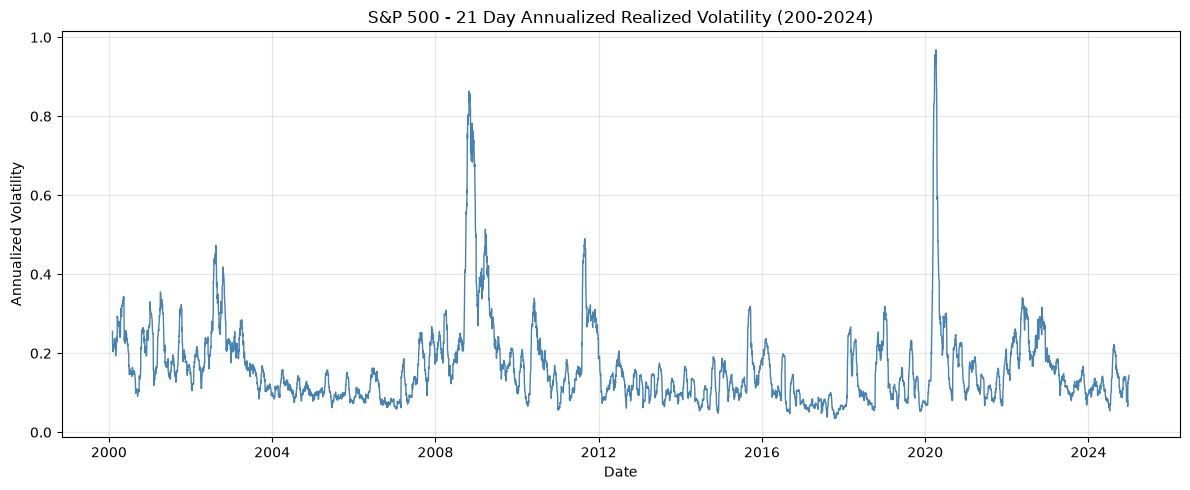

In [5]:
# standard deviation of returns (volatility)

sp500["realized_vol_21d"] = sp500["returns"].rolling(window=21).std()
sp500["realized_vol_21d_annualized"] = sp500["realized_vol_21d"] * (252 ** 0.5)
sp500[['Close', 'returns', 'realized_vol_21d', 'realized_vol_21d_annualized']].tail()


plt.figure(figsize=(12, 5))
plt.plot(sp500.index, sp500['realized_vol_21d_annualized'], color='steelblue', linewidth=1)
plt.title('S&P 500 - 21 Day Annualized Realized Volatility (200-2024)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# VIX 
vix['vix_change_5d'] = vix['Close'].pct_change(periods=5)
vix[['Close', 'vix_change_5d']].tail()




Price,Close,vix_change_5d
Date,,
2024-12-23,16.780001,0.142274
2024-12-24,14.270000,-0.100819
2024-12-26,14.730000,-0.466691
2024-12-27,15.950000,-0.337900
2024-12-30,17.400000,-0.052288


In [7]:
vix["Close"].loc['2024-12-15':'2024-12-30']

Date
2024-12-16    14.690000
2024-12-17    15.870000
2024-12-18    27.620001
2024-12-19    24.090000
2024-12-20    18.360001
2024-12-23    16.780001
2024-12-24    14.270000
2024-12-26    14.730000
2024-12-27    15.950000
2024-12-30    17.400000
Name: Close, dtype: float64